# 📌 Tugas 7 - Exploratory Data Analysis

> Copy template ini lalu kerjakan menggunakan template ini.

> Referensi untuk mengerjakan tugas :
> - https://colab.research.google.com/drive/1cCozod_L1um-5E4YDhD2RLoNXRNoylq9?usp=sharing
> - https://colab.research.google.com/drive/1_5ehUVxBed28qwAPLcR0C9aaYoaPiNZ3?usp=sharing
> - https://colab.research.google.com/drive/15KuXtQRyhSbMoimVmi0zjE06e9EwKT6s?usp=sharing
> - https://colab.research.google.com/drive/10BuLMoi9megpSFmn9AcYSXt8z6xCo3hT?usp=sharing

---

Tugas ini bertujuan untuk membantu kalian memahami Exploratory Data Analysis
Silakan download dataset di : https://www.kaggle.com/datasets/imdevskp/corona-virus-report lalu **pilih yang Worldometer.**

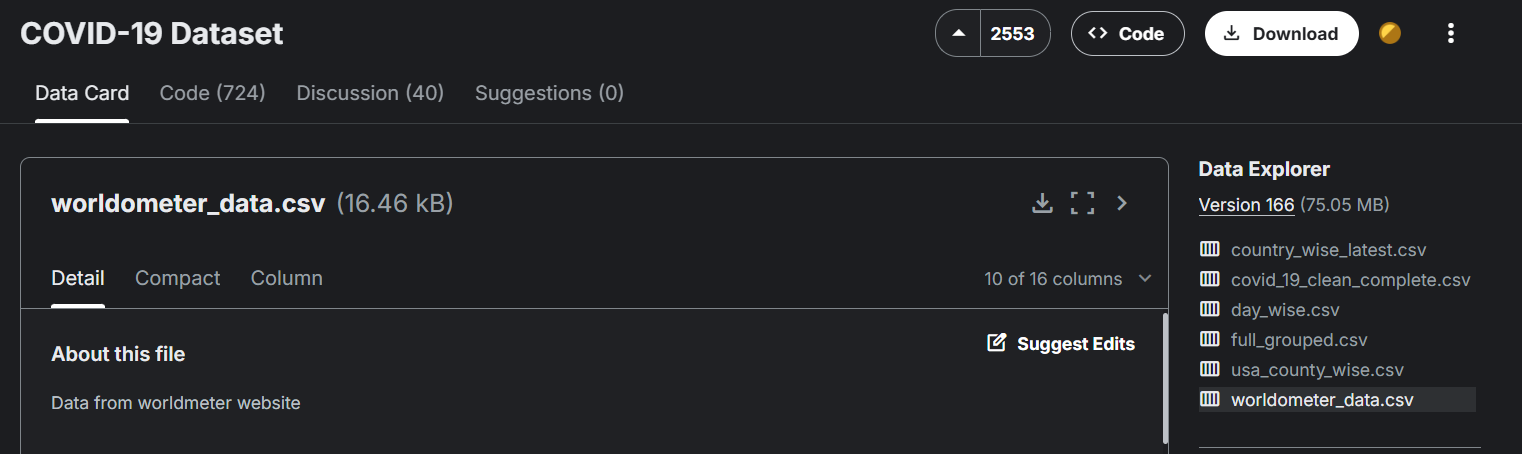

- Nama lengkap :
- Program : AI Development

Setiap langkah, setiap cell terdapat 'insight' hasil analisis dari kode yang dijalankan. Berikan insight sesuai dengan cell yang dijalankan.

**0. Import module yang diperlukan**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

**1. Membaca data**


> Silakan gunakan teknik membaca data teratas dan terbawah (cth: head(), tail()) yang tersedia pada pandas

> Cek tipe data dan missing value

> Tampilkan statistik deskriptif

In [ ]:
df = pd.read_csv('worldometer_data.csv')
df.head()

In [ ]:
print("Shape:", df.shape)
print()
print("Missing values per kolom:")
print(df.isnull().sum())

In [ ]:
df.describe()

Insight :

> Dataset berisi 209 negara dengan 16 kolom. Ada cukup banyak missing values terutama di kolom NewCases, NewDeaths, NewRecovered, dan TotalTests karena tidak semua negara rutin update data hariannya. Dari statistik deskriptif terlihat data kasus sangat timpang, ada negara dengan kasus sangat tinggi (AS jutaan) dan banyak negara dengan kasus kecil, sehingga nanti kemungkinan perlu pakai skala log untuk visualisasi.


**2. Analisis Distribusi**

> Plot distribusi TotalCases, TotalDeaths, dan TotalRecovered

> Buat histogram log-skala untuk kolom TotalCases

> Bandingkan populasi terhadap jumlah kasus (scatter plot)

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

kolom = ['TotalCases', 'TotalDeaths', 'TotalRecovered']
warna = ['steelblue', 'crimson', 'seagreen']

for i, (k, c) in enumerate(zip(kolom, warna)):
    axes[i].hist(df[k].dropna(), bins=40, color=c, edgecolor='black', alpha=0.7)
    axes[i].set_title(f'Distribusi {k}')
    axes[i].set_xlabel(k)
    axes[i].set_ylabel('Jumlah Negara')

plt.tight_layout()
plt.show()

In [ ]:
plt.figure(figsize=(10, 5))
plt.hist(np.log10(df['TotalCases'].dropna() + 1), bins=30, color='steelblue', edgecolor='black')
plt.title('Distribusi TotalCases (Skala Log)')
plt.xlabel('log10(TotalCases)')
plt.ylabel('Jumlah Negara')
plt.show()

In [ ]:
plt.figure(figsize=(10, 6))
plt.scatter(df['Population'], df['TotalCases'], alpha=0.5, color='steelblue', s=40)
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Populasi (log)')
plt.ylabel('TotalCases (log)')
plt.title('Populasi vs Total Kasus')
plt.show()

Insight :

> Distribusi TotalCases, TotalDeaths, dan TotalRecovered semuanya sangat skewed ke kanan, artinya mayoritas negara punya kasus relatif kecil tapi ada beberapa negara outlier dengan kasus sangat besar. Setelah diubah ke skala log, distribusinya jadi mendekati normal yang menunjukkan bahwa penyebaran kasus mengikuti pola eksponensial. Dari scatter plot populasi vs kasus terlihat ada korelasi positif, makin besar populasi cenderung makin banyak kasusnya, tapi tidak selalu proporsional karena ada negara kecil yang kasusnya tinggi.


**3. Analisis Per Benua (Continent)**

> Hitung total kasus, kematian, dan kesembuhan per benua

> Visualisasikan perbandingan kasus dan kematian antar benua

In [ ]:
per_benua = df.groupby('Continent')[['TotalCases', 'TotalDeaths', 'TotalRecovered']].sum().sort_values('TotalCases', ascending=False)
per_benua

In [ ]:
fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(per_benua.index))
lebar = 0.35

ax.bar(x - lebar/2, per_benua['TotalCases'], lebar, label='Kasus', color='steelblue')
ax.bar(x + lebar/2, per_benua['TotalDeaths'], lebar, label='Kematian', color='crimson')

ax.set_xticks(x)
ax.set_xticklabels(per_benua.index, rotation=30)
ax.set_ylabel('Jumlah')
ax.set_title('Perbandingan Total Kasus dan Kematian per Benua')
ax.set_yscale('log')
ax.legend()

plt.tight_layout()
plt.show()

Insight :

> North America menjadi benua dengan kasus tertinggi diikuti South America dan Europe. Sedangkan Australia/Oceania paling rendah karena faktor geografis yang terisolasi dan populasinya memang kecil. Yang menarik, rasio kematian terhadap kasus tidak sama di semua benua, beberapa benua punya angka kematian relatif tinggi dibanding jumlah kasusnya yang bisa disebabkan sistem kesehatan atau keterlambatan deteksi.


**4. Analisis Tes dan Positivity Rate**
> Buat kolom baru "Positivity Rate" = TotalCases / TotalTests

> Analisis negara-negara dengan positivity rate tertinggi

In [ ]:
df['Positivity Rate'] = df['TotalCases'] / df['TotalTests']
df[['Country/Region', 'TotalCases', 'TotalTests', 'Positivity Rate']].head()

In [ ]:
top_positivity = df[['Country/Region', 'Positivity Rate']].dropna().sort_values('Positivity Rate', ascending=False).head(10)

plt.figure(figsize=(10, 6))
plt.barh(top_positivity['Country/Region'], top_positivity['Positivity Rate'], color='tomato')
plt.xlabel('Positivity Rate')
plt.title('10 Negara dengan Positivity Rate Tertinggi')
plt.gca().invert_yaxis()
plt.show()

top_positivity

Insight :

> Positivity rate menunjukkan persentase tes yang hasilnya positif. Nilai yang tinggi biasanya menandakan dua hal: bisa jadi penyebarannya memang luas, atau jumlah tes yang dilakukan masih kurang sehingga yang dites kebanyakan memang orang yang sudah bergejala. WHO menyarankan positivity rate idealnya di bawah 5%, jadi negara-negara di top 10 ini kemungkinan butuh memperbanyak testing.


**5. Death Rate & Recovery Rate**
> Buat kolom baru "Death Rate" = TotalDeaths / TotalCases

> Buat kolom "Recovery Rate" = TotalRecovered / TotalCases

> Bandingkan death rate dan recovery rate secara global

In [ ]:
# Write your code here

In [ ]:
# Write your code here

In [ ]:
# Write your code here

Insight :

> Recovery rate rata-rata global jauh lebih tinggi dari death rate, yang artinya mayoritas pasien COVID sembuh. Namun sebarannya beragam antar negara, ada yang recovery rate-nya mendekati 100% ada juga yang masih rendah. Death rate yang tinggi di beberapa negara kemungkinan dipengaruhi kapasitas rumah sakit, demografi (proporsi lansia), dan keterlambatan penanganan.


**6. Serious/Critical Case Analysis**

> Visualisasi negara dengan jumlah kasus kritis tertinggi

> Bandingkan dengan jumlah kasus aktif

In [ ]:
# Write your code here

In [ ]:
# Write your code here

Insight :

> Negara dengan jumlah kasus kritis terbanyak adalah negara-negara yang juga punya kasus aktif paling banyak, yang masuk akal karena persentase pasien kritis biasanya tetap. Tapi rasionya tidak sama, ada negara yang jumlah kritisnya tinggi tapi aktifnya sudah turun, artinya sistem kesehatannya sedang fokus merawat pasien berat. Data ini penting untuk melihat beban rumah sakit di tiap negara.


**7. Negara dengan Performa Terbaik & Terburuk**

> Tampilkan top 10 negara dengan recovery rate tertinggi

> Tampilkan top 10 negara dengan death rate tertinggi

> Tampilkan top 10 negara dengan tests per 1M tertinggi

In [ ]:
# Write your code here

In [ ]:
# Write your code here

In [ ]:
# Write your code here

Insight :

> Negara dengan recovery rate tertinggi umumnya punya sistem kesehatan yang baik dan penanganan pandemi yang responsif. Sebaliknya, negara dengan death rate tertinggi rata-rata punya keterbatasan fasilitas kesehatan atau demografi yang rentan. Negara dengan tes per 1 juta populasi tertinggi biasanya adalah negara-negara kecil yang kaya atau negara yang serius melakukan tracing, dan ini menunjukkan seberapa agresif strategi testing suatu negara.


**8. Correlation Matrix**

> Buat heatmap korelasi untuk kolom numerik

> Apa yang menarik dari korelasi antara populasi, test, dan kasus?

In [ ]:
# Write your code here

In [ ]:
# Write your code here

Insight :

> Korelasi paling tinggi terlihat antara TotalCases, TotalDeaths, TotalRecovered, dan ActiveCases, hal ini wajar karena variabel-variabel ini saling terkait langsung. Populasi punya korelasi positif dengan TotalCases dan TotalTests, tapi tidak terlalu kuat, artinya besar populasi bukan satu-satunya faktor penentu banyak kasus. Yang menarik, Death Rate dan Recovery Rate korelasinya negatif dengan kebanyakan variabel lain, yang menunjukkan bahwa rate ini lebih dipengaruhi faktor kualitatif (sistem kesehatan, kebijakan) daripada sekadar jumlah absolut.


**9. Kesimpulan**

> Berikan kesimpulan soal dataset dan hasil EDA kamu.

> Dari hasil EDA dataset Worldometer COVID-19 ini bisa disimpulkan beberapa hal:
>
> 1. Penyebaran kasus COVID-19 di dunia sangat timpang, beberapa negara besar seperti Amerika Serikat, Brasil, dan India mendominasi jumlah kasus global, sementara banyak negara lain kasusnya jauh lebih kecil sehingga visualisasi lebih baik pakai skala log.
>
> 2. North America dan South America menjadi benua dengan kasus tertinggi, sedangkan Australia/Oceania paling rendah karena faktor geografis dan populasi yang kecil.
>
> 3. Positivity rate yang tinggi di beberapa negara menunjukkan jumlah tes yang masih kurang, bukan semata karena penyebarannya luas. WHO merekomendasikan positivity rate di bawah 5% untuk indikasi testing yang memadai.
>
> 4. Recovery rate rata-rata global tinggi, tapi death rate bervariasi antar negara tergantung kapasitas rumah sakit, demografi, dan kebijakan penanganan.
>
> 5. Variabel-variabel seperti TotalCases, TotalDeaths, TotalRecovered, dan ActiveCases saling berkorelasi kuat. Populasi berkorelasi positif dengan jumlah kasus tapi tidak terlalu kuat, artinya besar populasi bukan satu-satunya penentu.
>
> 6. Negara-negara dengan recovery rate tinggi dan tes per 1M tinggi umumnya punya sistem kesehatan yang lebih baik dan strategi penanganan yang lebih agresif.
